**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

PORTFOLIO_CSV = os.path.join(BASE_DIR, "DE_portfolio_log_returns.csv")

**Cell 2 — Load and prepare data**

In [2]:
data = pd.read_csv(PORTFOLIO_CSV, header=0)
xf = np.sort(data.iloc[:, 1].dropna().astype(float).values)

n = len(xf)
t = np.arange(1, n + 1) / (n + 1)

print("Observations:", n)
print(xf[:5], "...", xf[-5:])

Observations: 7522
[-0.54840029 -0.42584561 -0.34227729 -0.33353729 -0.30871087] ... [0.33116347 0.37186062 0.41311902 0.42301957 0.45282669]


**Cell 3 — Compute PP-plot coordinates**

In [3]:
theoretical_cdf = stats.norm.cdf(xf, loc=np.mean(xf), scale=np.std(xf))


**Cell 4 — PP-plot, display and save**

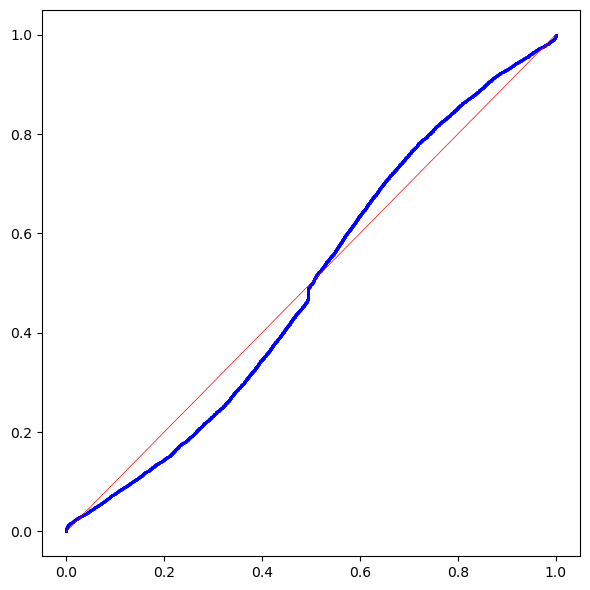

In [7]:
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.scatter(theoretical_cdf, t, color="blue", s=0.5)
ax1.plot([0, 1], [0, 1], color="red", linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pp_plot.png"), transparent=True, dpi=150)
plt.show()

**Cell 5 — Compute QQ-plot coordinates**

In [5]:
(osm, osr), (slope, intercept, _) = stats.probplot(xf, dist="norm")

**Cell 6 — QQ-plot, display and save**

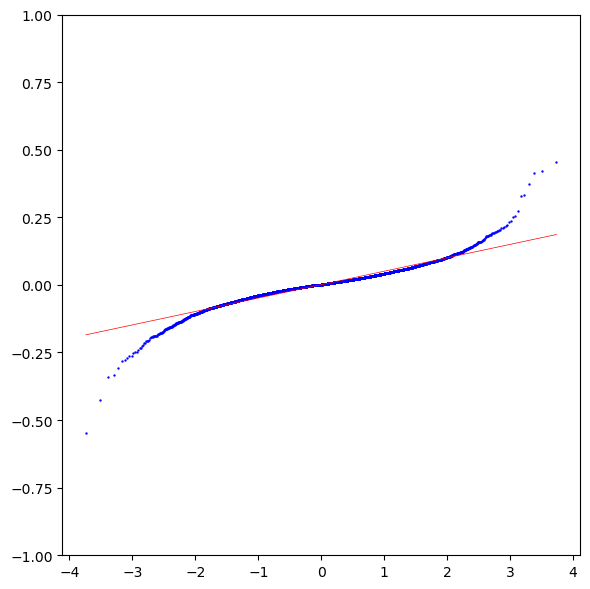

In [8]:
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.scatter(osm, osr, color="blue", s=0.5)
ax2.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=0.5)
ax2.set_ylim(-1, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "qq_plot.png"), transparent=True, dpi=150)
plt.show()